### Import Dependencies

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Read data and plot scatter chart

Text(0.5, 0, 'Weight')

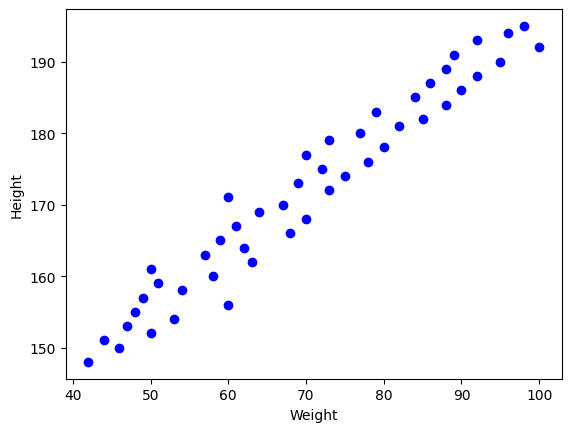

In [63]:
df = pd.read_csv('height-weight.csv')
df.head()

#scatter plot
plt.scatter(df['weight'],df['height'], color='blue')
plt.ylabel('Height')
plt.xlabel('Weight')

In [64]:
#Correlation Coefficient
df.corr()

,height,weight
height,1.000000,0.974405
weight,0.974405,1.000000


<Axes: >

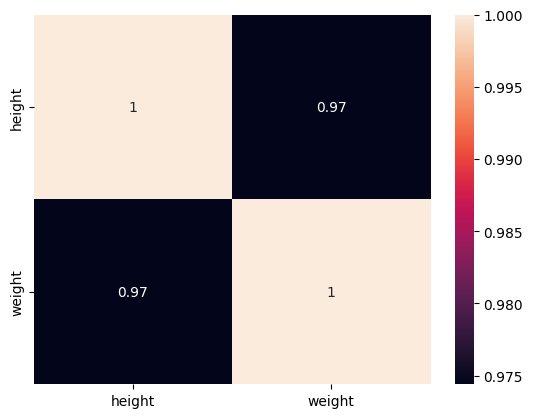

In [65]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True)

### independent and dependent features

In [66]:
#independent feature should be in 2D array or dataframe
X = df[['weight']]
np.array(X).shape

(47, 1)

In [67]:
#dependent feature can be in 1D array or series
Y = df['height']
np.array(Y).shape

(47,)

### Train and Test Split
- using sikit-learn

In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [69]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((35, 1), (12, 1), (35,), (12,))

### standardize the data
Z-score

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train.shape, X_test.shape

((35, 1), (12, 1))

### Apply Liner Regression

In [71]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [72]:
print("Model Coefficient:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficient: [13.50406492]
Model Intercept: 172.25714285714287


### Plot the Model Prediction - Best Fit Line

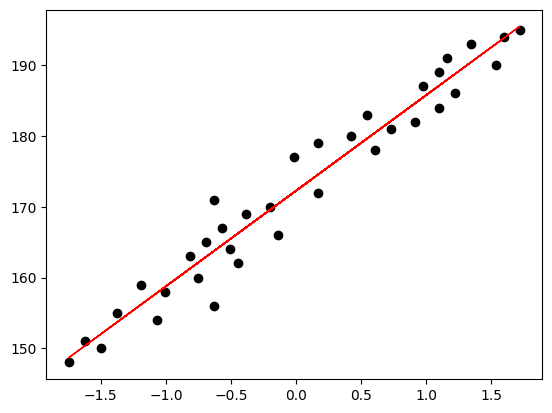

In [73]:
plt.scatter(X_train, Y_train, color='black')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=1)

### Doing Prediction for Test Data

In [74]:
#Prediction = Intercept + Coefficient * X_test
y_pred = model.predict(X_test)

### Performance Metrices
Predicted Data Vs Test Data 
- Mean Absolute Error
- Mean Square Error
- R2 Score
- Root Mean Squared Error

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse) 
print('R2 Score:', r2)


Mean Absolute Error: 2.708252946477439
Mean Squared Error: 9.727520717423742
Root Mean Squared Error: 3.1188973560256423
R2 Score: 0.94073603895291
